In [177]:
1

1

In [178]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributions as TD
import torch.optim as optim
from torch.distributions import Normal, Bernoulli, Independent
import torchvision
from torchvision import transforms
from torchvision.utils import make_grid

from collections import defaultdict
from tqdm.notebook import tqdm
from typing import List, Union
import gc
import os
import numpy as np
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score
from IPython.display import Image, display
from IPython.core.display import HTML
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib.animation as animation
from torch.linalg import svd

In [179]:
class SinusoidalEmbedding(nn.Module):
    def __init__(self, size: int, scale: float = 1.0):
        super().__init__()
        self.size = size
        self.scale = scale

    def forward(self, x: torch.Tensor):
        x = x * self.scale
        half_size = self.size // 2
        emb = torch.log(torch.Tensor([10000.0]).to(x.device)) / (half_size - 1)
        emb = torch.exp(-emb * torch.arange(half_size).to(x.device))
        emb = x.unsqueeze(-1).float() * emb.unsqueeze(0)
        emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=-1)
        return emb


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)

    def forward(self, x, t_emb):
        h = self.norm1(F.gelu(self.conv1(x)))
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.norm2(F.gelu(self.conv2(h)))
        return h


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.conv = ConvBlock(in_ch, out_ch, time_emb_dim)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x, t_emb):
        skip = self.conv(x, t_emb)
        return self.pool(skip), skip


class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = ConvBlock(out_ch * 2, out_ch, time_emb_dim)

    def forward(self, x, skip, t_emb):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x, t_emb)


class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, base_ch=64, time_emb_dim=128):
        super().__init__()

        self.time_proj = nn.Sequential(
            SinusoidalEmbedding(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.GELU()
        )

        self.down1 = DownBlock(in_channels, base_ch, time_emb_dim)      # 28 -> 14
        self.down2 = DownBlock(base_ch, base_ch * 2, time_emb_dim)      # 14 -> 7

        self.bottleneck = ConvBlock(base_ch * 2, base_ch * 4, time_emb_dim)

        self.up1 = UpBlock(base_ch * 4, base_ch * 2, time_emb_dim)      # 7 -> 14
        self.up2 = UpBlock(base_ch * 2, base_ch, time_emb_dim)          # 14 -> 28

        self.out = nn.Conv2d(base_ch, in_channels, 1)

    def forward(self, x, t):
        '''
        :x input [bs, C, H, W] - image
        :t 1d torch.LongTensor of timesteps
        '''
        t_emb = self.time_proj(t)

        x, skip1 = self.down1(x, t_emb)
        x, skip2 = self.down2(x, t_emb)

        x = self.bottleneck(x, t_emb)

        x = self.up1(x, skip2, t_emb)
        x = self.up2(x, skip1, t_emb)

        return self.out(x)

In [180]:
# Setup Device
DEVICE = "cuda:2" if torch.cuda.is_available() else "cpu"

# MNIST Dataset (same transform as fft_process_fm: scale to [-1, 1])
train_dataset = torchvision.datasets.MNIST(
    root='.',
    train=True,
    download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x * 2 - 1)
    ])
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [181]:
def svd_truncate(x, r):
    # x: [B, C, H, W]
    B, C, H, W = x.shape
    x_flat = x.view(B * C, H, W)

    U, S, Vh = torch.linalg.svd(x_flat, full_matrices=False)

    U_r = U[:, :, :r]
    S_r = S[:, :r]
    Vh_r = Vh[:, :r, :]

    x_r = torch.matmul(U_r, torch.matmul(torch.diag_embed(S_r), Vh_r))
    x_r = x_r.view(B, C, H, W)
    return x_r, S

# FM Velocity

In [ ]:
# Model initialization with exact hyperparameters from fft_process_fm
model = SimpleUNet(in_channels=1, base_ch=64, time_emb_dim=64).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

# Check parameter count
print("Model parameters:", sum([p.numel() for p in model.parameters()]))

In [ ]:
losses = []

log_every_n = 10
num_train_steps = 1500
num_epoches = 10
step = 0
HIGH = 28

model.train()

for epoch in range(num_epoches):
    for images, labels in tqdm(train_loader):
        images = images.to(DEVICE)
        b = images.shape[0]

        # x0: Clean image (Data)
        x0 = images

        # x1: Target distribution (Standard Normal / Noise)
        x1 = torch.randn_like(x0)

        # t: Time ~ Uniform[0, 1]
        t = torch.rand(b, device=DEVICE)

        # OT Path interpolation: x_t = (1 - t) * x0 + t * x1
        t_view = t.view(-1, 1, 1, 1)
        xt = (1 - t_view) * x0 + t_view * x1

        # Target Vector Field: v = x1 - x0
        target_v = x1 - x0

        # Predict Vector Field
        # We scale t by 1000 because SinusoidalEmbedding expects values > 1 for good frequency coverage
        vt = model(xt, t * 1000)

        # Loss: MSE for Flow Matching
        loss = F.mse_loss(vt, target_v)

        optimizer.zero_grad()
        loss.backward()

        # Clip grad norm (same as fft_process_fm)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        losses.append(loss.item())

        step += 1

        if step >= num_train_steps:
            break

    if step >= num_train_steps:
        break

# Plot Loss
plt.plot(losses)
plt.title("Flow Matching Training Loss")
plt.show()

In [ ]:
@torch.no_grad()
def sample_fm(model, n_samples=16, steps=100):
    model.eval()

    # Start from Standard Normal (noise, which is x1 in training)
    x = torch.randn(n_samples, 1, 28, 28).to(DEVICE)

    # Pre-compute time array (from t=1 to t=0)
    t_array = torch.linspace(1, 0, steps + 1).to(DEVICE)
    dt = -1.0 / steps  # Negative because we're going backward

    # Integrate ODE backward: from t=1 (noise) to t=0 (data)
    for i in range(steps):
        # Current time
        t = t_array[i].repeat(n_samples)

        # Predict velocity at current position and time
        v = model(x, t * 1000)

        # Euler step backward
        x = x + v * dt

    return x.detach().cpu()

# Generate and display samples
samples = sample_fm(model, n_samples=16, steps=100)

# Denormalize (-1, 1) -> (0, 1)
samples = (samples + 1) / 2
samples = samples.clamp(0, 1)

grid = make_grid(samples, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.title("Generated MNIST Digits (Flow Matching)")
plt.show()

In [ ]:
import os
from PIL import Image

num_samples = 10000
batch_size = 1024
num_steps = 10

model.eval()

for num_steps in range(1, 28):
    save_dir = f'./MNIST/generate_fm_velocity/{num_steps}/'
    os.makedirs(save_dir, exist_ok=True)

    count = 0
    for batch_idx in tqdm(range(num_samples // batch_size + 1), desc='Generating and saving images'):
        current_batch_size = min(batch_size, num_samples - count)
        if current_batch_size <= 0:
            break
                        
        with torch.no_grad():
            x_t = sample_fm(model, n_samples=batch_size, steps=num_steps)

        for i in range(current_batch_size):
            img = x_t[i][0].cpu()
            
            img_np = ((img.numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)
            pil_img = Image.fromarray(img_np, mode='L')
            
            pil_img.save(os.path.join(save_dir, f'gen_{count:05d}.png'))
            count += 1

# FM X0

In [182]:
fix_seed(SEED)

In [183]:
# Model initialization with exact hyperparameters from fft_process_fm
model = SimpleUNet(in_channels=1, base_ch=64, time_emb_dim=64).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

# Check parameter count
print("Model parameters:", sum([p.numel() for p in model.parameters()]))

Model parameters: 1910017


 60%|█████▉    | 561/938 [00:05<00:03, 110.42it/s]


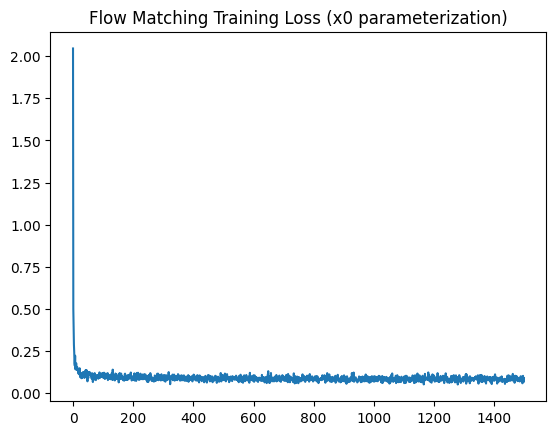

In [184]:
losses = []

log_every_n = 10
num_train_steps = 1500
num_epoches = 10
step = 0
HIGH = 28

model.train()

for epoch in range(num_epoches):
    for images, labels in tqdm(train_loader):
        images = images.to(DEVICE)
        b = images.shape[0]

        # x0: Clean image (data)
        x0 = images

        # x1: Noise sample
        x1 = torch.randn_like(x0)

        # t: Time ~ Uniform[0, 1]
        t = torch.rand(b, device=DEVICE)

        # Interpolation path
        # CHANGED: keep the same path, but now we train the model to predict x0
        t_view = t.view(-1, 1, 1, 1)
        xt = (1 - t_view) * x0 + t_view * x1

        # CHANGED: target is x0, not the vector field
        target_x0 = x0

        # Predict x0
        # CHANGED: model output is interpreted as x0_hat
        x0_hat = model(xt, t * 1000)

        # CHANGED: x0-parameterization loss
        loss = F.mse_loss(x0_hat, target_x0)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        losses.append(loss.item())
        step += 1

        if step >= num_train_steps:
            break

    if step >= num_train_steps:
        break

plt.plot(losses)
plt.title("Flow Matching Training Loss (x0 parameterization)")
plt.show()

In [185]:
@torch.no_grad()
def sample_images_x0(model, n_samples=16, steps=100, device=DEVICE):
    model.eval()

    # Start from pure noise at t = 1
    x = torch.randn(n_samples, 1, 28, 28, device=device)

    # Time grid: 1 -> 0
    ts = torch.linspace(1.0, 1e-3, steps + 1, device=device)

    for i in range(steps):
        t = ts[i]
        t_next = ts[i + 1]
        dt = t - t_next

        t_batch = torch.full((n_samples,), t, device=device)

        # Model predicts x0_hat from current xt
        x0_hat = model(x, t_batch * 1000)

        # Implied forward velocity from x_t = (1-t)x0 + t x1
        # v_hat = dx/dt = (x_t - x0_hat) / t
        v_hat = (x - x0_hat) / (t_batch.view(-1, 1, 1, 1) + 1e-6)

        # Euler step backward in time
        x = x - dt * v_hat

    return x

In [186]:
import os
from PIL import Image

num_samples = 10000
batch_size = 1024
num_steps = 10

model.eval()

for num_steps in range(1, 28):
    save_dir = f'./MNIST/generate_fm_x0_v2/{num_steps}/'
    os.makedirs(save_dir, exist_ok=True)

    count = 0
    for batch_idx in tqdm(range(num_samples // batch_size + 1), desc='Generating and saving images'):
        current_batch_size = min(batch_size, num_samples - count)
        if current_batch_size <= 0:
            break
                        
        with torch.no_grad():
            x_t = sample_images_x0(model, n_samples=batch_size, steps=num_steps)

        for i in range(current_batch_size):
            img = x_t[i][0].cpu()
            
            img_np = ((img.numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)
            pil_img = Image.fromarray(img_np, mode='L')
            
            pil_img.save(os.path.join(save_dir, f'gen_{count:05d}.png'))
            count += 1

Generating and saving images: 100%|██████████| 10/10 [00:20<00:00,  2.02s/it]


# FM x0 + SVD Loss Random 

In [ ]:
def compute_rank_from_spectrum(S, t):
    # S: [B*C, min(H,W)]
    # t: [B]

    Bc, R = S.shape
    device = S.device

    # Explained variance
    energy = S**2
    total_energy = energy.sum(dim=1, keepdim=True)
    cum_energy = torch.cumsum(energy, dim=1)
    ev = cum_energy / (total_energy + 1e-8)

    # Signal fraction q(t)
    t_expanded = t.repeat_interleave(S.shape[0] // t.shape[0])
    q = (1 - t_expanded)**2 / ((1 - t_expanded)**2 + t_expanded**2 + 1e-8)

    # Find smallest r such that EV >= q
    r = (ev >= q.unsqueeze(1)).float().argmax(dim=1)

    return r.clamp(min=1)  # avoid r=0 for stability

In [ ]:
# Model initialization with exact hyperparameters from fft_process_fm
model = SimpleUNet(in_channels=1, base_ch=64, time_emb_dim=64).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

# Check parameter count
print("Model parameters:", sum([p.numel() for p in model.parameters()]))

In [ ]:
losses = []

model.train()
step = 0
num_train_steps = 1500
num_epoches = 10

for epoch in range(num_epoches):
    for images, _ in tqdm(train_loader):
        optimizer.zero_grad()
        images = images.to(DEVICE)
        B = images.shape[0]

        x0 = images
        x1 = torch.randn_like(x0)

        t = torch.rand(B, device=DEVICE)
        t_view = t.view(-1, 1, 1, 1)

        xt = (1 - t_view) * x0 + t_view * x1

        x0_hat = model(xt, t * 1000)

        # r = семплируется из какого-т ораспределения (для начала равномерного) r.shape: [batch_size]
        r = torch.randint(low=1, high=HIGH + 1, size=(B,), device=DEVICE)

        x0_lowrank = []
        for i in range(B):
            ri = int(r[i].item())

            x0_i = x0[i:i+1]

            x0_r, _ = svd_truncate(x0_i, ri)

            x0_lowrank.append(x0_r)

        x0_lowrank = torch.cat(x0_lowrank, dim=0)

        x0_hat_lowrank = []
        for i in range(B):
            ri = int(r[i].item())

            x0_hat_i = x0_hat[i:i+1]

            x0_hat_r, _ = svd_truncate(x0_hat_i, ri)

            x0_hat_lowrank.append(x0_hat_r)

        x0_hat_lowrank = torch.cat(x0_hat_lowrank, dim=0)


        loss = F.mse_loss(x0_hat_lowrank, x0_lowrank)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        losses.append(loss.item())
        step += 1

        if step >= num_train_steps:
            break

    if step >= num_train_steps:
        break


plt.plot(losses)
plt.show()


In [ ]:
@torch.no_grad()
def sample_images_x0(model, n_samples=16, steps=100, device=DEVICE):
    model.eval()

    # Start from pure noise at t = 1
    x = torch.randn(n_samples, 1, 28, 28, device=device)

    # Time grid: 1 -> 0
    ts = torch.linspace(1.0, 1e-3, steps + 1, device=device)

    for i in range(steps):
        t = ts[i]
        t_next = ts[i + 1]
        dt = t - t_next

        t_batch = torch.full((n_samples,), t, device=device)

        # Model predicts x0_hat from current xt
        x0_hat = model(x, t_batch * 1000)

        # Implied forward velocity from x_t = (1-t)x0 + t x1
        # v_hat = dx/dt = (x_t - x0_hat) / t
        v_hat = (x - x0_hat) / (t_batch.view(-1, 1, 1, 1) + 1e-6)

        # Euler step backward in time
        x = x - dt * v_hat

    return x

In [ ]:
samples = sample_images_x0(model, n_samples=16, steps=50, device=DEVICE)

# map from [-1, 1] to [0, 1] for plotting
samples = samples.clamp(-1, 1)
samples = (samples + 1) / 2

grid = make_grid(samples, nrow=4)
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
plt.axis("off")
plt.title("Generated samples")
plt.show()

In [ ]:
import os
from PIL import Image

num_samples = 10000
batch_size = 1024
num_steps = 10

model.eval()

for num_steps in range(1, 28):
    save_dir = f'./MNIST/generate_fm_x0_random_svd/{num_steps}/'
    os.makedirs(save_dir, exist_ok=True)

    count = 0
    for batch_idx in tqdm(range(num_samples // batch_size + 1), desc='Generating and saving images'):
        current_batch_size = min(batch_size, num_samples - count)
        if current_batch_size <= 0:
            break
                        
        with torch.no_grad():
            x_t = sample_images_x0(model, n_samples=batch_size, steps=num_steps)

        for i in range(current_batch_size):
            img = x_t[i][0].cpu()
            
            img_np = ((img.numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)
            pil_img = Image.fromarray(img_np, mode='L')
            
            pil_img.save(os.path.join(save_dir, f'gen_{count:05d}.png'))
            count += 1

# FM x0 + SVD Loss Linear Aligned

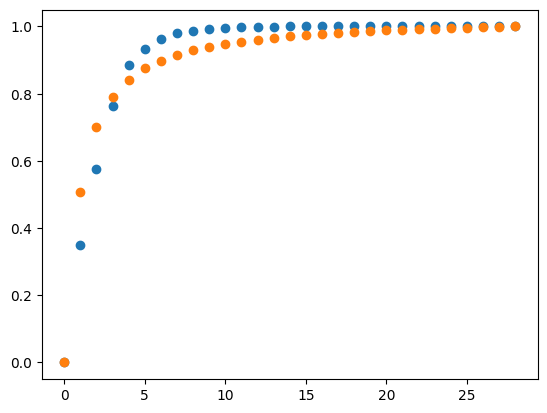

In [17]:
# Create test image
x0 = train_dataset[3][0][0]
x0 = (x0 - x0.mean()) / (x0.std() + 1e-8)  # Normalize for fair comparison

def preserved_energy_ratio(image, t):
    U, S, Vh = svd(image, full_matrices=False)

    total_energy = torch.sum(S**2)
    preserved_energy = torch.sum(S[:t]**2)
    return preserved_energy / total_energy

def preserved_energy_fm(image, t):
    return (1 - t) ** 2

ranks = list(range(0, 29))
svd_energies = [preserved_energy_ratio(x0, r) for r in ranks]


def shift_timesteps(t, shift):
    return shift * t / (1 + (shift - 1) * t)

ts = torch.linspace(1, 0, 29)
ts = shift_timesteps(
    ts, 0.015
)

fm_energies = [preserved_energy_fm(x0, t) for t in ts]

plt.scatter(ranks, svd_energies)
plt.scatter(ranks, fm_energies)

In [124]:
import torch, numpy as np, matplotlib.pyplot as plt
import random


def shift_timesteps(t, shift):
    return shift * t / (1 + (shift - 1) * t)


def preserved_energy_ratio(image, t, U_S_Vh = None):
    if U_S_Vh is None:
        U, S, Vh = svd(image, full_matrices=False)
    else:
        U, S, Vh = U_S_Vh

    total_energy = torch.sum(S**2)
    preserved_energy = torch.sum(S[:t]**2)
    return preserved_energy / total_energy


def preserved_energy_fm(image, t):
    return (1 - t) ** 2


def t_from_energy(energy):
    # energy = (1 - t) ** 2
    # -1 * (sqrt(energy) - 1) = t
    return -1 * (energy ** 0.5 - 1)


def get_t_energy_boundaries(image):
    ranks = list(range(0, 28))

    U, S, Vh = svd(image, full_matrices=False)

    svd_energies = [preserved_energy_ratio(x0, r, U_S_Vh=(U, S, Vh)) for r in ranks]
    flow_match_ts = [t_from_energy(energy) for energy in svd_energies]  

    return flow_match_ts

In [168]:
SEED = 42

def fix_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) 


fix_seed(SEED)

In [169]:
# Model initialization with exact hyperparameters from fft_process_fm
model = SimpleUNet(in_channels=1, base_ch=64, time_emb_dim=64).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

# Check parameter count
print("Model parameters:", sum([p.numel() for p in model.parameters()]))

Model parameters: 1910017


In [170]:
# r_scheduling

def r_linear(t, r_max=32, r_min=1):
    return (r_max - (r_max - r_min) * t).long()

In [171]:
T = 28
t_grid = torch.linspace(1.0, 0.0, T, device=DEVICE)

r_grid = r_linear(t_grid, r_max=28, r_min=1)

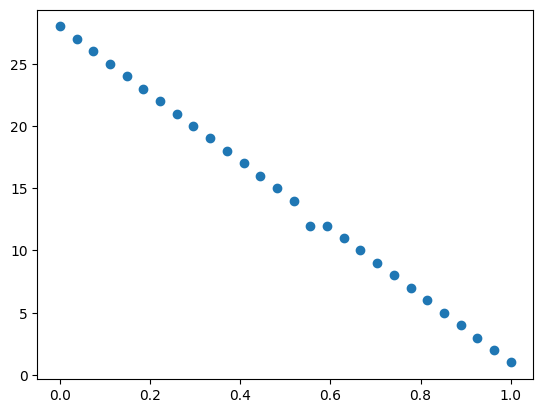

In [172]:
plt.scatter(t_grid.cpu(), r_grid.cpu())

 60%|█████▉    | 561/938 [00:49<00:33, 11.32it/s]


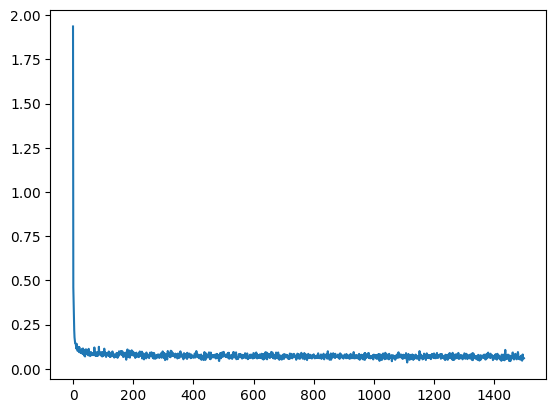

In [173]:
losses = []

model.train()
step = 0
num_train_steps = 1500
num_epoches = 10

for epoch in range(num_epoches):
    for images, _ in tqdm(train_loader):
        optimizer.zero_grad()
        images = images.to(DEVICE)
        B = images.shape[0]

        x0 = images
        x1 = torch.randn_like(x0)

        idx = torch.randint(low=0, high=T, size=(B,), device=DEVICE)

        # CHANGED: use the predefined schedules
        t = t_grid[idx]                 # shape [B]
        r = r_grid[idx].long()          # shape [B], integer ranks 1..28

        t_view = t.view(-1, 1, 1, 1)

        xt = (1 - t_view) * x0 + t_view * x1

        x0_hat = model(xt, t * 1000)

        x0_lowrank = []
        for i in range(B):
            ri = int(r[i].item())

            x0_i = x0[i:i+1]

            x0_r, _ = svd_truncate(x0_i, ri)

            x0_lowrank.append(x0_r)

        x0_lowrank = torch.cat(x0_lowrank, dim=0)

        x0_hat_lowrank = []
        for i in range(B):
            ri = int(r[i].item())

            x0_hat_i = x0_hat[i:i+1]

            x0_hat_r, _ = svd_truncate(x0_hat_i, ri)

            x0_hat_lowrank.append(x0_hat_r)

        x0_hat_lowrank = torch.cat(x0_hat_lowrank, dim=0)


        loss = F.mse_loss(x0_hat_lowrank, x0_lowrank)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        losses.append(loss.item())
        step += 1

        if step >= num_train_steps:
            break

    if step >= num_train_steps:
        break


plt.plot(losses)
plt.show()

In [174]:
@torch.no_grad()
def sample_images_x0(model, n_samples=16, steps=14, device=DEVICE):
    model.eval()

    # Start from pure noise at t = 1
    x = torch.randn(n_samples, 1, 28, 28, device=device)

    # Time grid: 1 -> 0
    ts = shift_timesteps(torch.linspace(1.0, 1e-3, steps + 1, device=device), 3)

    for i in range(steps):
        t = ts[i]
        t_next = ts[i + 1]
        dt = t - t_next

        t_batch = torch.full((n_samples,), t, device=device)

        # Model predicts x0_hat from current xt
        x0_hat = model(x, t_batch * 1000)

        # Implied forward velocity from x_t = (1-t)x0 + t x1
        # v_hat = dx/dt = (x_t - x0_hat) / t
        v_hat = (x - x0_hat) / (t_batch.view(-1, 1, 1, 1) + 1e-6)

        # Euler step backward in time
        x = x - dt * v_hat

    return x

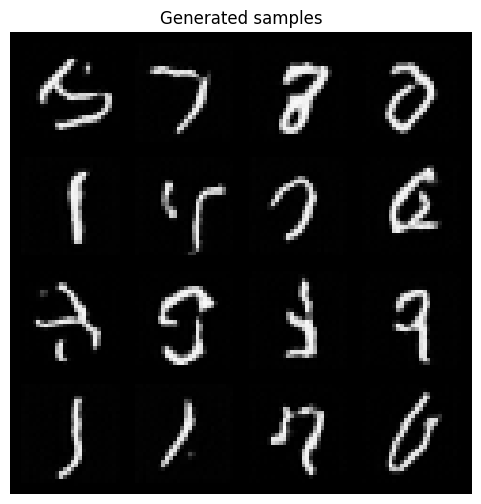

In [175]:
fix_seed(SEED)
samples = sample_images_x0(model, n_samples=16, steps=28, device=DEVICE)

# map from [-1, 1] to [0, 1] for plotting
samples = samples.clamp(-1, 1)
samples = (samples + 1) / 2

grid = make_grid(samples, nrow=4)
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
plt.axis("off")
plt.title("Generated samples")
plt.show()

In [176]:
import os
from PIL import Image

num_samples = 10000
batch_size = 1024
num_steps = 10

model.eval()

for num_steps in range(1, 28):
    save_dir = f'./MNIST/generate_fm_x0_lin_aligned_svd_v2/{num_steps}/'
    os.makedirs(save_dir, exist_ok=True)

    count = 0
    for batch_idx in tqdm(range(num_samples // batch_size + 1), desc='Generating and saving images'):
        current_batch_size = min(batch_size, num_samples - count)
        if current_batch_size <= 0:
            break
                        
        with torch.no_grad():
            x_t = sample_images_x0(model, n_samples=batch_size, steps=num_steps)

        for i in range(current_batch_size):
            img = x_t[i][0].cpu()
            
            img_np = ((img.numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)
            pil_img = Image.fromarray(img_np, mode='L')
            
            pil_img.save(os.path.join(save_dir, f'gen_{count:05d}.png'))
            count += 1

Generating and saving images: 100%|██████████| 10/10 [00:17<00:00,  1.75s/it]


# FM x0 + SVD Loss Power Aligned

# Power 1/2

In [141]:
fix_seed(SEED)

In [142]:
def r_power(t, r_max=32, r_min=1, p=2):
    r = r_min + (r_max - r_min) * (1 - t) ** p
    return r.long()


r_grid = r_power(t_grid, r_max=28, r_min=1, p=0.5)

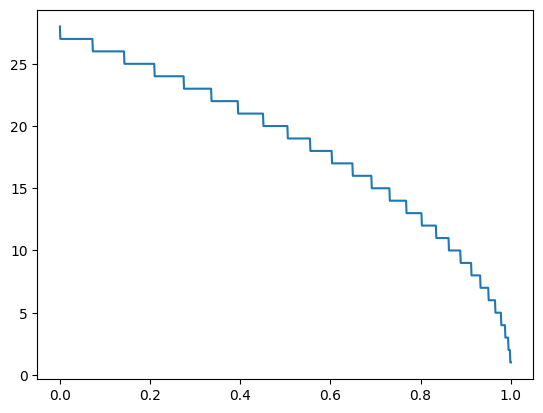

In [143]:
plt.plot(t_grid.cpu(), r_grid.cpu())

In [144]:
# Model initialization with exact hyperparameters from fft_process_fm
model = SimpleUNet(in_channels=1, base_ch=64, time_emb_dim=64).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

# Check parameter count
print("Model parameters:", sum([p.numel() for p in model.parameters()]))

Model parameters: 1910017


 60%|█████▉    | 561/938 [00:49<00:33, 11.33it/s]


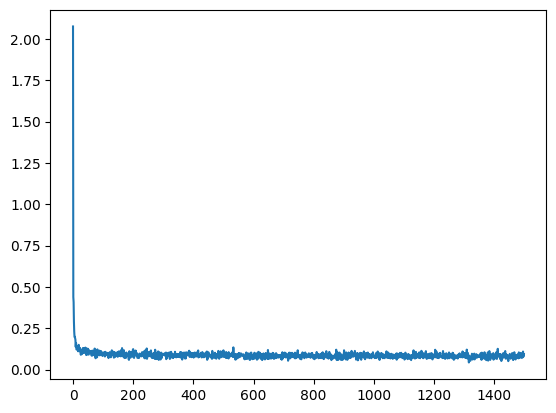

In [145]:
losses = []

model.train()
step = 0
num_train_steps = 1500
num_epoches = 10

for epoch in range(num_epoches):
    for images, _ in tqdm(train_loader):
        optimizer.zero_grad()
        images = images.to(DEVICE)
        B = images.shape[0]

        x0 = images
        x1 = torch.randn_like(x0)

        idx = torch.randint(low=0, high=T, size=(B,), device=DEVICE)

        # CHANGED: use the predefined schedules
        t = t_grid[idx]                 # shape [B]
        r = r_grid[idx].long()          # shape [B], integer ranks 1..28

        t_view = t.view(-1, 1, 1, 1)

        xt = (1 - t_view) * x0 + t_view * x1

        x0_hat = model(xt, t * 1000)

        x0_lowrank = []
        for i in range(B):
            ri = int(r[i].item())

            x0_i = x0[i:i+1]

            x0_r, _ = svd_truncate(x0_i, ri)

            x0_lowrank.append(x0_r)

        x0_lowrank = torch.cat(x0_lowrank, dim=0)

        x0_hat_lowrank = []
        for i in range(B):
            ri = int(r[i].item())

            x0_hat_i = x0_hat[i:i+1]

            x0_hat_r, _ = svd_truncate(x0_hat_i, ri)

            x0_hat_lowrank.append(x0_hat_r)

        x0_hat_lowrank = torch.cat(x0_hat_lowrank, dim=0)


        loss = F.mse_loss(x0_hat_lowrank, x0_lowrank)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        losses.append(loss.item())
        step += 1

        if step >= num_train_steps:
            break

    if step >= num_train_steps:
        break


plt.plot(losses)
plt.show()

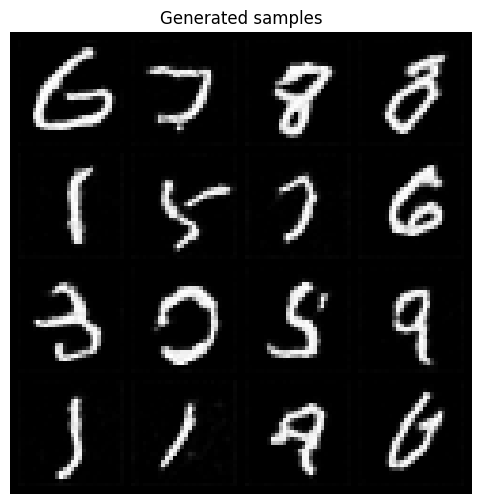

In [155]:
fix_seed(SEED)
samples = sample_images_x0(model, n_samples=16, steps=28, device=DEVICE)

# map from [-1, 1] to [0, 1] for plotting
samples = samples.clamp(-1, 1)
samples = (samples + 1) / 2

grid = make_grid(samples, nrow=4)
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
plt.axis("off")
plt.title("Generated samples")
plt.show()

In [156]:
import os
from PIL import Image

num_samples = 10000
batch_size = 1024
num_steps = 10

model.eval()

for num_steps in range(1, 28):
    save_dir = f'./MNIST/generate_fm_x0_sqrt_aligned_svd/{num_steps}/'
    os.makedirs(save_dir, exist_ok=True)

    count = 0
    for batch_idx in tqdm(range(num_samples // batch_size + 1), desc='Generating and saving images'):
        current_batch_size = min(batch_size, num_samples - count)
        if current_batch_size <= 0:
            break
                        
        with torch.no_grad():
            x_t = sample_images_x0(model, n_samples=batch_size, steps=num_steps)

        for i in range(current_batch_size):
            img = x_t[i][0].cpu()
            
            img_np = ((img.numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)
            pil_img = Image.fromarray(img_np, mode='L')
            
            pil_img.save(os.path.join(save_dir, f'gen_{count:05d}.png'))
            count += 1

Generating and saving images: 100%|██████████| 10/10 [00:20<00:00,  2.04s/it]


## Power 2

In [159]:
fix_seed(SEED)

In [160]:
def r_power(t, r_max=32, r_min=1, p=2):
    r = r_min + (r_max - r_min) * (1 - t) ** p
    return r.long()


r_grid = r_power(t_grid, r_max=28, r_min=1, p=2)

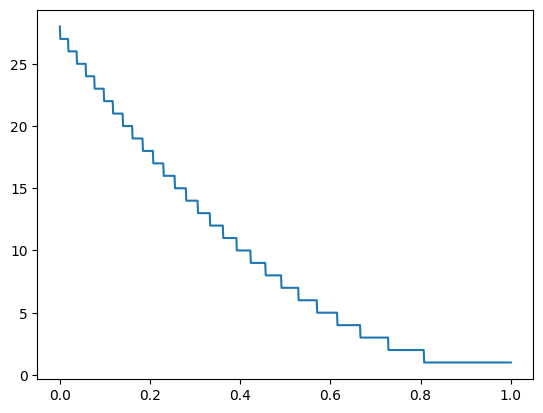

In [161]:
plt.plot(t_grid.cpu(), r_grid.cpu())

In [162]:
# Model initialization with exact hyperparameters from fft_process_fm
model = SimpleUNet(in_channels=1, base_ch=64, time_emb_dim=64).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

# Check parameter count
print("Model parameters:", sum([p.numel() for p in model.parameters()]))

Model parameters: 1910017


 60%|█████▉    | 561/938 [00:49<00:33, 11.28it/s]


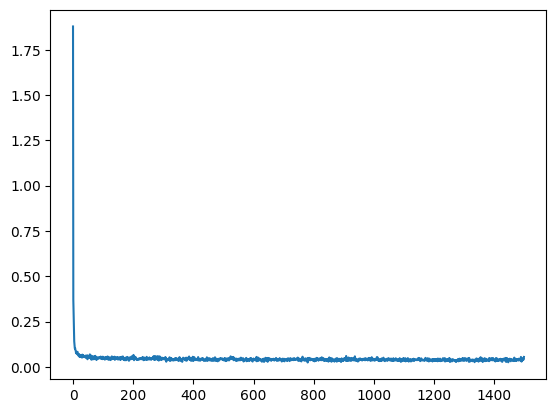

In [163]:
losses = []

model.train()
step = 0
num_train_steps = 1500
num_epoches = 10

for epoch in range(num_epoches):
    for images, _ in tqdm(train_loader):
        optimizer.zero_grad()
        images = images.to(DEVICE)
        B = images.shape[0]

        x0 = images
        x1 = torch.randn_like(x0)

        idx = torch.randint(low=0, high=T, size=(B,), device=DEVICE)

        # CHANGED: use the predefined schedules
        t = t_grid[idx]                 # shape [B]
        r = r_grid[idx].long()          # shape [B], integer ranks 1..28

        t_view = t.view(-1, 1, 1, 1)

        xt = (1 - t_view) * x0 + t_view * x1

        x0_hat = model(xt, t * 1000)

        x0_lowrank = []
        for i in range(B):
            ri = int(r[i].item())

            x0_i = x0[i:i+1]

            x0_r, _ = svd_truncate(x0_i, ri)

            x0_lowrank.append(x0_r)

        x0_lowrank = torch.cat(x0_lowrank, dim=0)

        x0_hat_lowrank = []
        for i in range(B):
            ri = int(r[i].item())

            x0_hat_i = x0_hat[i:i+1]

            x0_hat_r, _ = svd_truncate(x0_hat_i, ri)

            x0_hat_lowrank.append(x0_hat_r)

        x0_hat_lowrank = torch.cat(x0_hat_lowrank, dim=0)


        loss = F.mse_loss(x0_hat_lowrank, x0_lowrank)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        losses.append(loss.item())
        step += 1

        if step >= num_train_steps:
            break

    if step >= num_train_steps:
        break


plt.plot(losses)
plt.show()

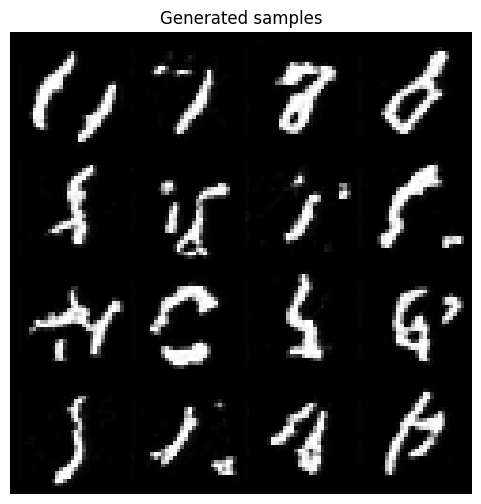

In [164]:
fix_seed(SEED)
samples = sample_images_x0(model, n_samples=16, steps=28, device=DEVICE)

# map from [-1, 1] to [0, 1] for plotting
samples = samples.clamp(-1, 1)
samples = (samples + 1) / 2

grid = make_grid(samples, nrow=4)
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
plt.axis("off")
plt.title("Generated samples")
plt.show()

In [165]:
import os
from PIL import Image

num_samples = 10000
batch_size = 1024
num_steps = 10

model.eval()

for num_steps in range(1, 28):
    save_dir = f'./MNIST/generate_fm_x0_poly_aligned_svd/{num_steps}/'
    os.makedirs(save_dir, exist_ok=True)

    count = 0
    for batch_idx in tqdm(range(num_samples // batch_size + 1), desc='Generating and saving images'):
        current_batch_size = min(batch_size, num_samples - count)
        if current_batch_size <= 0:
            break
                        
        with torch.no_grad():
            x_t = sample_images_x0(model, n_samples=batch_size, steps=num_steps)

        for i in range(current_batch_size):
            img = x_t[i][0].cpu()
            
            img_np = ((img.numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)
            pil_img = Image.fromarray(img_np, mode='L')
            
            pil_img.save(os.path.join(save_dir, f'gen_{count:05d}.png'))
            count += 1

Generating and saving images: 100%|██████████| 10/10 [00:17<00:00,  1.76s/it]
